# 19. Derin MLP ile Rakam Sınıflandırma

**Kategori:** Derin Öğrenme  
**Gerçek veri seti:** scikit-learn Digits  
**Veri kaynağı:** [https://scikit-learn.org/stable/datasets/toy_dataset.html#digits-dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#digits-dataset)  
**Amaç:** Birden fazla gizli katmanlı sinir ağıyla 8×8 rakam görüntülerini sınıflandırmak.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veri hazırlama ve görsel EDA

Örnek: 1797 | Girdi boyutu: 64 | Sınıf: 10


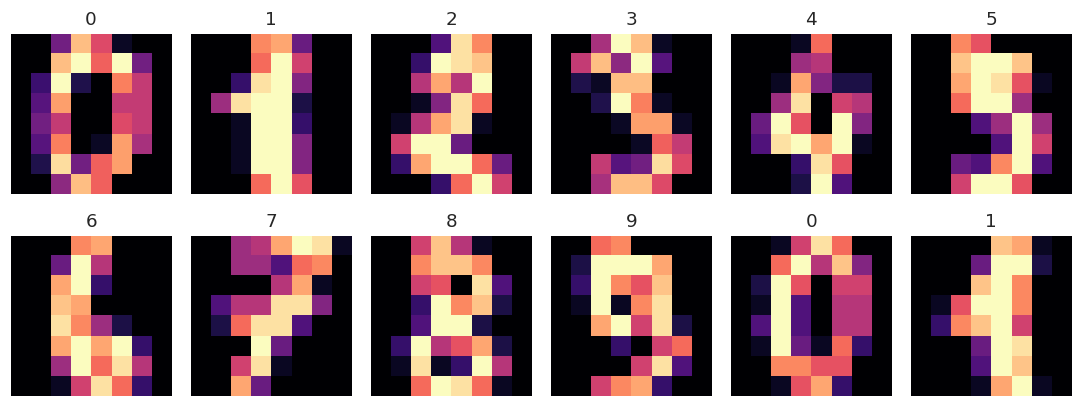

In [2]:
from sklearn.datasets import load_digits
d = load_digits()
X, y = d.data / 16.0, d.target
print("Örnek:", X.shape[0], "| Girdi boyutu:", X.shape[1], "| Sınıf:", len(np.unique(y)))
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), d.images[:12], y[:12]):
    ax.imshow(image, cmap="magma"); ax.set_title(str(label)); ax.axis("off")
plt.tight_layout(); plt.show()

## 2. Baseline ve çok katmanlı sinir ağı

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE
)
baseline = LogisticRegression(max_iter=2500).fit(X_train, y_train)
mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation="relu",
                    batch_size=64, learning_rate_init=.001, max_iter=250,
                    early_stopping=True, validation_fraction=.15,
                    n_iter_no_change=15, random_state=RANDOM_STATE).fit(X_train, y_train)
fitted = {"Lojistik baseline": baseline, "Derin MLP": mlp}
scores = pd.Series({name: accuracy_score(y_test, model.predict(X_test))
                    for name, model in fitted.items()}, name="accuracy").sort_values(ascending=False)
display(scores.to_frame().round(4))
pred = mlp.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.86      1.00      0.92        36
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.94      0.97        36
           7       0.97      1.00      0.99        36
           8       0.97      0.83      0.89        35
           9       1.00      1.00      1.00        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



,accuracy
Derin MLP,0.9722
Lojistik baseline,0.9556


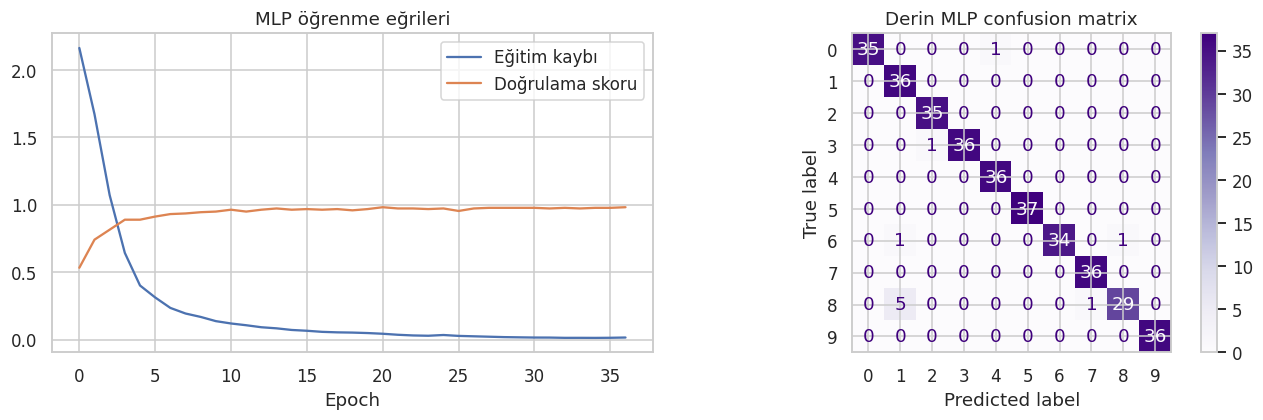

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp.loss_curve_, label="Eğitim kaybı")
if hasattr(mlp, "validation_scores_"):
    axes[0].plot(mlp.validation_scores_, label="Doğrulama skoru")
axes[0].set(title="MLP öğrenme eğrileri", xlabel="Epoch"); axes[0].legend()
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Purples", ax=axes[1])
axes[1].set_title("Derin MLP confusion matrix")
plt.tight_layout(); plt.show()

In [5]:
joblib.dump({"best_name": scores.index[0], "best_model": fitted[scores.index[0]],
             "all_models": fitted, "mlp_model": mlp, "image_shape": (8, 8),
             "accuracy": scores.to_dict()}, MODEL_DIR / "19_derin_mlp_rakam.joblib")
json.dump({"mlp_accuracy": float(accuracy_score(y_test, pred)), "epochs": int(mlp.n_iter_),
           "baseline_accuracy": float(scores["Lojistik baseline"])},
          open(RESULT_DIR / "19_derin_mlp_rakam.json", "w"), indent=2)

## Sonuç

Sinir ağı üç gizli katmanla tanımlandı; erken durdurma için eğitim içinden ayrı doğrulama bölümü
kullanıldı. Eğitim kaybı, doğrulama skoru ve baseline karşılaştırması gösterildi. Böylece model yalnızca
tek satırda eğitilip kaydedilmedi; öğrenme davranışı da analiz edildi.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **MLP ile görüntü sınıflandırma** biçimindedir.
Bu notebookta **üç katmanlı mimari, baseline, erken durdurma, öğrenme eğrileri ve hata matrisi** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).